In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense,Conv2D, MaxPooling2D,Flatten
from tensorflow.keras.layers import Dropout


In [2]:
import tensorflow.keras as keras

train=keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\shai\Desktop\ml_projects\GIT\DEEP_LEARNING\DATASETS\archive",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 3670 files belonging to 2 classes.


In [3]:
#checking the shape
for images, labels in train.take(1):
    print(images.shape)
    print(labels.shape)

(32, 256, 256, 3)
(32,)


In [4]:
#preprocessing
def process(image,label):
    image = image/255
    return image,label
train=train.map(process)


In [5]:
model=([
    Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.5),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(5,activation='softmax')

])

c:\Users\shai\Desktop\ml_projects\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
from tensorflow.keras.models import Sequential

In [7]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(5,activation='softmax'))

In [8]:
from tensorflow.keras.optimizers import Adam
evl=model.compile(optimizer=Adam(learning_rate=0.00001),loss='SparseCategoricalCrossentropy',metrics=['accuracy'])

In [9]:
import numpy as np
x=np.array(images)
y=np.array(labels)

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
print(x_train.shape)
y_train.shape
x_train.shape
y_test.shape

(25, 256, 256, 3)


(7,)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,789 (10.49 MB)

 Trainable params: 2,750,789 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history=model.fit(x_train,y_train,batch_size=32,epochs=30,validation_data=(x_test,y_test))

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0400 - loss: 7.6914 - val_accuracy: 0.1429 - val_loss: 4.4036
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step - accuracy: 0.2400 - loss: 3.8526 - val_accuracy: 0.7143 - val_loss: 1.5744
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step - accuracy: 0.6000 - loss: 1.6052 - val_accuracy: 0.7143 - val_loss: 0.8739
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step - accuracy: 0.7600 - loss: 1.0002 - val_accuracy: 0.7143 - val_loss: 0.7667
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step - accuracy: 0.8000 - loss: 0.9304 - val_accuracy: 0.7143 - val_loss: 0.7303
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step - accuracy: 0.8400 - loss: 0.8985 - val_accuracy: 0.7143 - val_loss: 0.6963
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step - accuracy: 0.8400 - loss: 0.8554 - val_accuracy: 0.7143 - val_loss: 0.6365
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step - accuracy: 0.8400 - loss: 0.7419 - val_accuracy: 0.7143 - val_loss: 0.

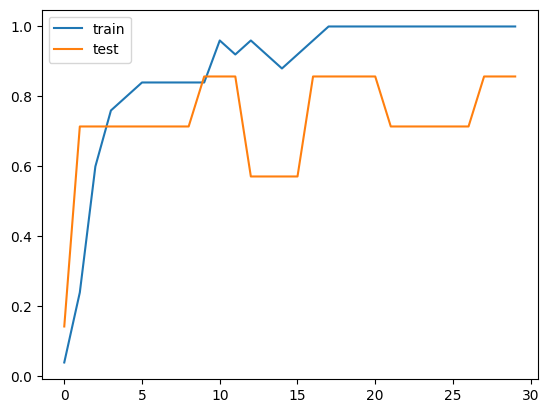

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

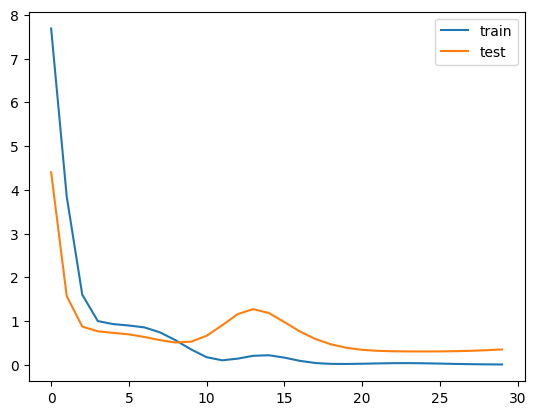

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

In [16]:
base =tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(256,256,3),
    pooling='avg',
    classes=5,
    classifier_activation='softmax',
    name='densenet121',
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [17]:
mmodel=Sequential([
    base,
    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.5),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(5,activation='softmax')
])

In [18]:
from tensorflow.keras.optimizers import Adam
evl=model.compile(optimizer=Adam(learning_rate=0.0001),loss='SparseCategoricalCrossentropy',metrics=['accuracy'])

In [19]:
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

In [20]:
history=model.fit(train,validation_data=(x_test,y_test),epochs=3)

Epoch 1/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 72s 609ms/step - accuracy: 0.7488 - loss: 0.6215 - val_accuracy: 0.8571 - val_loss: 20.1034
Epoch 2/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 65s 567ms/step - accuracy: 0.7482 - loss: 0.5690 - val_accuracy: 0.8571 - val_loss: 27.6142
Epoch 3/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 65s 566ms/step - accuracy: 0.7482 - loss: 0.5524 - val_accuracy: 0.8571 - val_loss: 19.5020
